In [9]:

import pandas as pd 
import numpy as np
import ast
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.pipeline import Pipeline as Pipeline
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder, MultiLabelBinarizer,FunctionTransformer,StandardScaler
from sklearn.metrics import (accuracy_score,average_precision_score,precision_score,
                             recall_score,f1_score,roc_curve,
                             roc_auc_score,precision_recall_curve)
import matplotlib.pyplot as plt
import joblib
from custom_transformer import MultiLabelBinarizerTransformer







In [10]:
df=pd.read_csv("training_data.csv")
df["insurance_type"]=df["insurance_type"].fillna("NONE")


In [11]:
df["diag_category"] = df["diag_category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [12]:
# train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["readmitted_30d","readmitted_7d","diag_rank","patient_state","hospital_state"]),df["readmitted_30d"],test_size=0.25,random_state=42,stratify=df["readmitted_30d"])

In [ ]:
print(X_train.shape)

(90000, 22)
       age gender  bpl_card insurance_type  comorbidity_count  \
54826   52      F         1           NONE                  0   

       prev_admissions  los_days admit_type ward_type discharge_type  ...  \
54826                0       2.0   Elective       HDU      Recovered  ...   

       hba1c  creatinine  haemoglobin  systolic_bp   tier  beds teaching  \
54826    6.0         3.9         10.6        104.0  tier3  61.0      0.0   

       out_of_pocket_inr  cost_category    diag_category  
54826             4410.0            Lab  [Genitourinary]  

[1 rows x 22 columns]


In [14]:
# impute transformer
trf1=ColumnTransformer([
    ("impute_age",SimpleImputer(strategy="median",add_indicator=True),[0]),
    ("impute_gender",SimpleImputer(strategy="constant",fill_value="Unknown",add_indicator=True),[1]),
    ("impute_bpl_card",SimpleImputer(strategy="constant",fill_value=-1,add_indicator=True),[2]),
    ("impute_insurance_type",SimpleImputer(strategy="constant",fill_value="Unknown",add_indicator=True),[3]),
    ("impute_charlson_index",SimpleImputer(strategy="median",add_indicator=True),[11]),
    ("impute_hba1c",SimpleImputer(strategy="median",add_indicator=True),[12]),
    ("impute_creatinine",SimpleImputer(strategy="median",add_indicator=True),[13]),
    ("impute_haemoglobin",SimpleImputer(strategy="median",add_indicator=True),[14]),
    ("impute_systolic_bp",SimpleImputer(strategy="median",add_indicator=True),[15]),
    ("impute_out_of_pocket_inr",SimpleImputer(strategy="median",add_indicator=True),[19]),
    ("impute_cost_category",SimpleImputer(strategy="most_frequent",add_indicator=True),[20]),
    ("missing_indicators", MissingIndicator(features="all"), 
        [0,1,2,3,11,12,13,14,15,19,20])
    ],remainder="passthrough"
)


In [15]:
#one_hot_encoding_transformer/ordinal_transformer
trf2=ColumnTransformer([
    ("ohe_gender",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[1]),
    ("ohe_insurance_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[3]),
    ("ohe_cost_category",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[10]),
    ("ohe_admit_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[25]),
    ("ohe_ward_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[26]),
    ("ohe_discharge_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[27]),
    ("ordinal_tier",OrdinalEncoder(categories=[['tier3', 'tier2', 'tier1']]),[29])
    ],remainder="passthrough")
  

In [21]:

# multi_label_binarizer_transformer for diag_category
trf3 = ColumnTransformer([
    ("mlb_diag_category", MultiLabelBinarizerTransformer(classes=[
        "Cardiovascular", "Endocrine", "Respiratory", "Infectious",
        "Gastrointestinal", "Neoplasm", "Injury", "Neurological",
        "Genitourinary", "Obstetric", "Perinatal"
    ]), [-1])
], remainder="passthrough")


In [45]:
# Scalar_transformer
trf4=ColumnTransformer([
    ("scale",StandardScaler(),slice(0,59))
])

In [46]:
# Model
trf5= LogisticRegression(penalty="l2",random_state=42,solver="saga",C=0.01,class_weight="balanced")

In [47]:
pipe = Pipeline([
    ("step1_imputation", trf1),
    ("step2_encoding", trf2),
    ("step3_mlb",trf3),
    ("step4_scaling", trf4),
    ("step5_model",trf5)
])


In [48]:
pipe.fit(X_train,y_train)

,steps,"[('step1_imputation', ...), ('step2_encoding', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_age', ...), ('impute_gender', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:

y_pred = pipe.predict(X_test)
print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")


accuracy_score = 70.54%
precision_score = 24.07%
recall_score = 69.06%
f1_score = 35.7%


In [50]:
y_score=pipe.predict_proba(X_test)[:,1]

Best Threshold = 0.654
Precision = 0.339, Recall = 0.464, F1 = 0.392


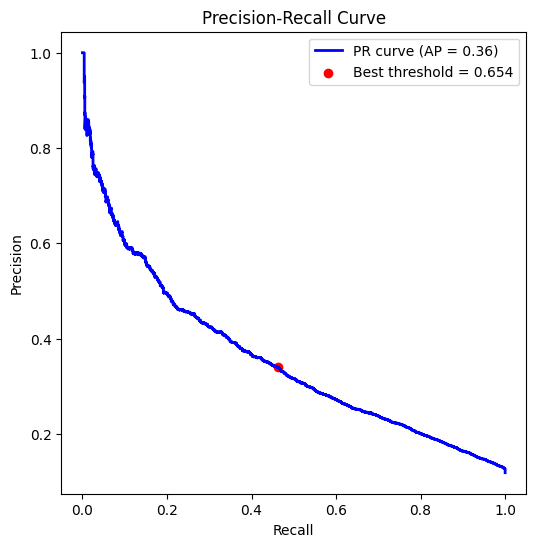

In [51]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
avg_prec = average_precision_score(y_test, y_score)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
ix = f1_scores.argmax()
best_thresh = thresholds[ix]

print(f"Best Threshold = {best_thresh:.3f}")
print(f"Precision = {precision[ix]:.3f}, Recall = {recall[ix]:.3f}, F1 = {f1_scores[ix]:.3f}")

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color="blue", lw=2, label=f"PR curve (AP = {avg_prec:.2f})")
plt.scatter(recall[ix], precision[ix], marker="o", color="red", 
            label=f"Best threshold = {best_thresh:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

In [52]:
y_pred = (y_score >= best_thresh).astype(int)

# Evaluate
print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")

accuracy_score = 82.96%
precision_score = 33.93%
recall_score = 46.37%
f1_score = 39.19%


In [53]:
joblib.dump(pipe,"pipeline.pkl")
joblib.dump((X_test, y_test), "test_data.pkl")

['test_data.pkl']

In [56]:
preprocessor = pipe[:-1]  
model = pipe.named_steps["step5_model"]  
X_test_transformed = preprocessor.transform(X_test)
import shap

c:\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Python310\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


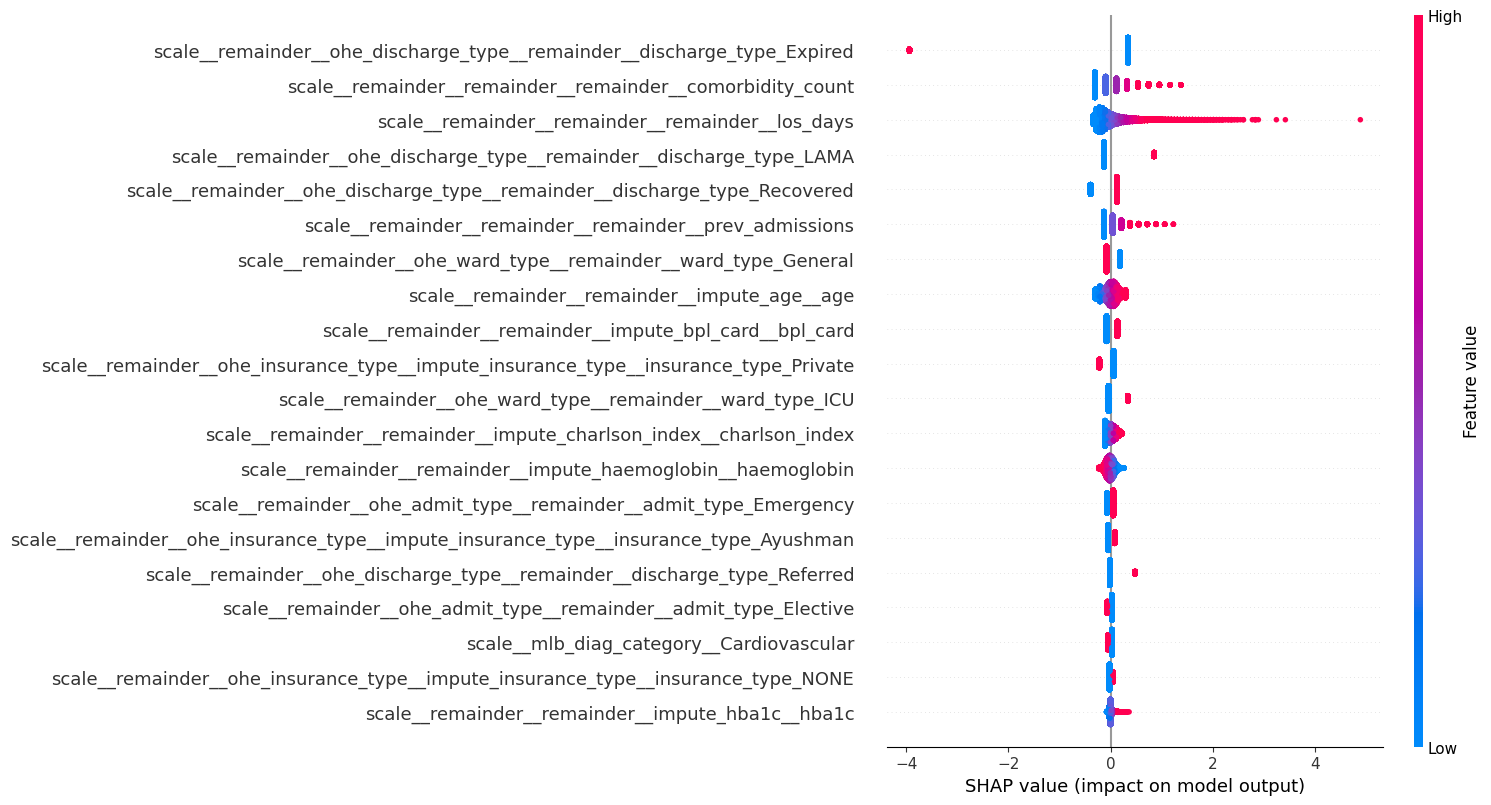

In [57]:
explainer = shap.LinearExplainer(model, X_test_transformed, feature_names=preprocessor.get_feature_names_out())
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=preprocessor.get_feature_names_out())